<a href="https://colab.research.google.com/github/fariafarzana11/food_adulteration/blob/main/Food_Adulteration_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q flask scikit-learn pandas matplotlib joblib scipy

In [2]:
import json, warnings, threading
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
Path("models").mkdir(exist_ok=True)

## Load the data


In [3]:
from pathlib import Path

CSV = "food_adulteration_data.csv"
if not Path(CSV).exists() and Path("data", CSV).exists():
    CSV = str(Path("data", CSV))

if not Path(CSV).exists():
    try:
        from google.colab import files
        up = files.upload()               # choose food_adulteration_data.csv
        CSV = next(iter(up))
    except ImportError:
        raise FileNotFoundError("Put food_adulteration_data.csv next to this notebook.")

df = pd.read_csv(CSV)
print(df.shape)
df.head()

(1000, 10)


,adulteration_id,product_name,brand,category,adulterant,detection_date,detection_method,severity,health_risk,action_taken
0,1,Butter,BrandB,Meat,Artificial sweeteners,5/11/2024,Microbiological Analysis,Moderate,Low,Product Recall
1,2,Chicken,BrandC,Dairy,Coloring agents,5/23/2024,Sensory Evaluation,Severe,Medium,Warning Issued
2,3,Yogurt,BrandC,Meat,Artificial sweeteners,2/17/2024,Sensory Evaluation,Severe,High,Investigation Launched
3,4,Wine,BrandB,Beverages,Coloring agents,5/16/2024,Spectroscopy,Minor,Medium,Product Recall
4,5,Bread,BrandD,Dairy,Water,6/6/2024,Chemical Analysis,Severe,Medium,Warning Issued


In [4]:
print(df.dtypes, "\n")
print("Missing values:\n", df.isna().sum(), "\n")
print("Duplicate IDs:", df["adulteration_id"].duplicated().sum())

adulteration_id      int64
product_name        object
brand               object
category            object
adulterant          object
detection_date      object
detection_method    object
severity            object
health_risk         object
action_taken        object
dtype: object 

Missing values:
 adulteration_id     0
product_name        0
brand               0
category            0
adulterant          0
detection_date      0
detection_method    0
severity            0
health_risk         0
action_taken        0
dtype: int64 

Duplicate IDs: 0


## Cleaning and feature engineering

In [5]:
df = df.drop_duplicates(subset="adulteration_id").dropna().copy()
df["detection_date"] = pd.to_datetime(df["detection_date"], format="%m/%d/%Y")
df["month"] = df["detection_date"].dt.month
df["day_of_week"] = df["detection_date"].dt.dayofweek

CAT_FEATURES = ["product_name", "brand", "category", "adulterant", "detection_method"]
NUM_FEATURES = ["month", "day_of_week"]
FEATURES = CAT_FEATURES + NUM_FEATURES
TARGETS = ["severity", "health_risk", "action_taken"]

print("Date range:", df.detection_date.min().date(), "to", df.detection_date.max().date())
df[FEATURES + TARGETS].head()

Date range: 2024-01-01 to 2024-06-30


,product_name,brand,category,adulterant,detection_method,month,day_of_week,severity,health_risk,action_taken
0,Butter,BrandB,Meat,Artificial sweeteners,Microbiological Analysis,5,5,Moderate,Low,Product Recall
1,Chicken,BrandC,Dairy,Coloring agents,Sensory Evaluation,5,3,Severe,Medium,Warning Issued
2,Yogurt,BrandC,Meat,Artificial sweeteners,Sensory Evaluation,2,5,Severe,High,Investigation Launched
3,Wine,BrandB,Beverages,Coloring agents,Spectroscopy,5,3,Minor,Medium,Product Recall
4,Bread,BrandD,Dairy,Water,Chemical Analysis,6,3,Severe,Medium,Warning Issued


## Exploratory data analysis

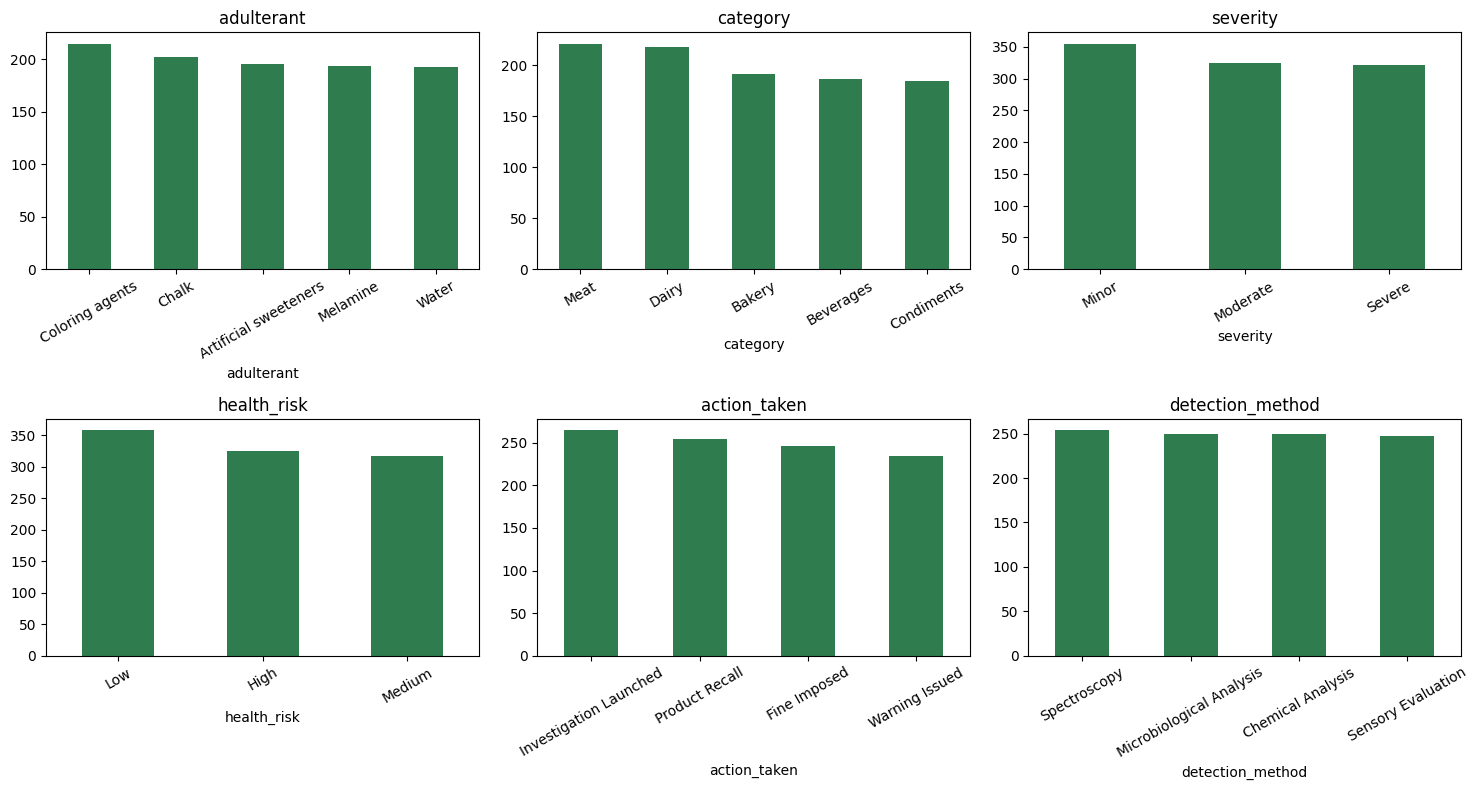

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), ["adulterant", "category", "severity", "health_risk", "action_taken", "detection_method"]):
    df[col].value_counts().plot(kind="bar", ax=ax, color="#2f7d4f")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

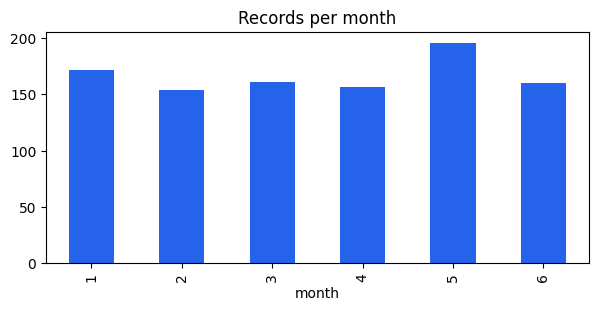

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
df.groupby("month").size().plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Records per month"); plt.show()

### Is there any signal in the data?
A chi-square test of independence checks whether a feature is related to a target. A **p-value below 0.05** would suggest a real relationship.

In [8]:
rows = []
for t in TARGETS:
    for f in CAT_FEATURES:
        p = chi2_contingency(pd.crosstab(df[f], df[t]))[1]
        rows.append({"target": t, "feature": f, "p_value": round(p, 3)})
pvals = pd.DataFrame(rows).pivot(index="feature", columns="target", values="p_value")
print(pvals)
print("\nSmallest p-value:", pvals.values.min())
print("Severity vs health_risk p-value:", round(chi2_contingency(pd.crosstab(df.severity, df.health_risk))[1], 3))

target            action_taken  health_risk  severity
feature                                              
adulterant               0.826        0.503     0.742
brand                    0.768        0.357     0.859
category                 0.978        0.826     0.430
detection_method         0.361        0.628     0.908
product_name             0.941        0.982     0.286

Smallest p-value: 0.286
Severity vs health_risk p-value: 0.589


In [9]:
# Logical consistency check: which products fall under which category?
pd.crosstab(df["product_name"], df["category"])

category,Bakery,Beverages,Condiments,Dairy,Meat
product_name,,,,,
Beef,19,11,13,24,25
Bread,10,16,28,32,17
Butter,15,20,14,13,17
Cheese,14,19,18,20,17
Chicken,20,16,23,29,32
Honey,24,23,14,12,17
Juice,27,24,22,18,33
Milk,20,12,22,24,29
Wine,19,28,16,18,16


If products such as Butter or Wine are spread across Meat, Dairy and Beverages, the data is internally inconsistent, which is another sign it was generated randomly.

## Build the preprocessing pipeline and candidate models

In [10]:
def make_pipeline(model):
    pre = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_FEATURES),
        ("num", "passthrough", NUM_FEATURES),
    ])
    return Pipeline([("pre", pre), ("clf", model)])

def candidates():
    return {
        "Baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                                random_state=RANDOM_STATE, n_jobs=-1),
        "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=2,
                                                        random_state=RANDOM_STATE),
    }

## Train, cross-validate and evaluate


In [11]:
X = df[FEATURES]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
summary, trained, splits = {}, {}, {}

for target in TARGETS:
    y = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    splits[target] = (X_te, y_te)

    print(f"\n=== {target} ===")
    cv_scores = {}
    for name, model in candidates().items():
        s = cross_val_score(make_pipeline(model), X_tr, y_tr, cv=cv, scoring="accuracy")
        cv_scores[name] = float(s.mean())
        print(f"  {name:26s} CV accuracy = {s.mean():.3f} (+/- {s.std():.3f})")

    real = {k: v for k, v in cv_scores.items() if not k.startswith("Baseline")}
    best_name = max(real, key=real.get)
    best = make_pipeline(candidates()[best_name]).fit(X_tr, y_tr)
    base = make_pipeline(candidates()["Baseline (most frequent)"]).fit(X_tr, y_tr)

    pred = best.predict(X_te)
    summary[target] = {
        "best_model": best_name,
        "cv_scores": cv_scores,
        "test_accuracy": round(accuracy_score(y_te, pred), 4),
        "test_macro_f1": round(f1_score(y_te, pred, average="macro"), 4),
        "baseline_accuracy": round(accuracy_score(y_te, base.predict(X_te)), 4),
    }
    print(f"  -> best: {best_name} | test acc = {summary[target]['test_accuracy']} "
          f"| baseline acc = {summary[target]['baseline_accuracy']}")
    print(classification_report(y_te, pred, zero_division=0))

    # refit on all data for the final model
    trained[target] = make_pipeline(candidates()[best_name]).fit(X, y)


=== severity ===
  Baseline (most frequent)   CV accuracy = 0.355 (+/- 0.003)
  Logistic Regression        CV accuracy = 0.329 (+/- 0.018)
  Random Forest              CV accuracy = 0.340 (+/- 0.027)
  Gradient Boosting          CV accuracy = 0.340 (+/- 0.019)
  -> best: Random Forest | test acc = 0.295 | baseline acc = 0.355
              precision    recall  f1-score   support

       Minor       0.34      0.42      0.38        71
    Moderate       0.26      0.18      0.22        65
      Severe       0.26      0.27      0.26        64

    accuracy                           0.29       200
   macro avg       0.29      0.29      0.28       200
weighted avg       0.29      0.29      0.29       200


=== health_risk ===
  Baseline (most frequent)   CV accuracy = 0.358 (+/- 0.002)
  Logistic Regression        CV accuracy = 0.336 (+/- 0.018)
  Random Forest              CV accuracy = 0.341 (+/- 0.033)
  Gradient Boosting          CV accuracy = 0.334 (+/- 0.025)
  -> best: Random Forest 

## Results

In [12]:
res = pd.DataFrame(summary).T[["best_model", "test_accuracy", "test_macro_f1", "baseline_accuracy"]]
res

,best_model,test_accuracy,test_macro_f1,baseline_accuracy
severity,Random Forest,0.295,0.2849,0.355
health_risk,Random Forest,0.37,0.364,0.36
action_taken,Random Forest,0.205,0.1985,0.265


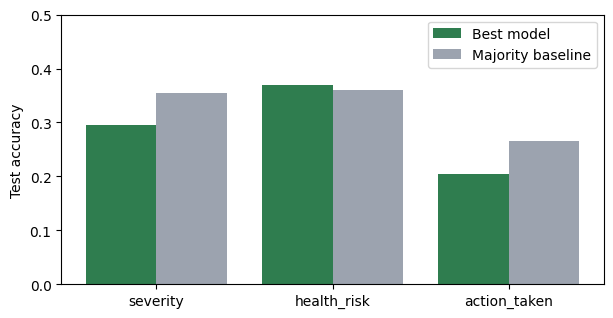

In [13]:
fig, ax = plt.subplots(figsize=(7, 3.5))
x = np.arange(len(TARGETS))
ax.bar(x - 0.2, [summary[t]["test_accuracy"] for t in TARGETS], 0.4, label="Best model", color="#2f7d4f")
ax.bar(x + 0.2, [summary[t]["baseline_accuracy"] for t in TARGETS], 0.4, label="Majority baseline", color="#9ca3af")
ax.set_xticks(x); ax.set_xticklabels(TARGETS); ax.set_ylabel("Test accuracy"); ax.set_ylim(0, 0.5); ax.legend()
plt.show()

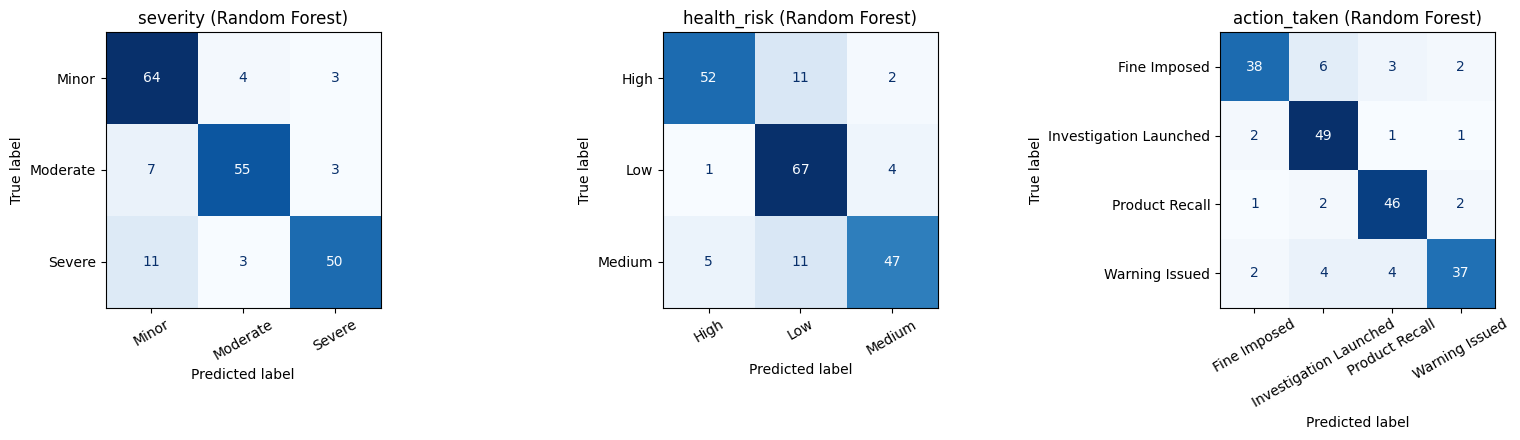

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, t in zip(axes, TARGETS):
    X_te, y_te = splits[t]
    ConfusionMatrixDisplay.from_estimator(trained[t], X_te, y_te, ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{t} ({summary[t]['best_model']})")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

##  Save the models

In [15]:
for t, m in trained.items():
    joblib.dump(m, f"models/{t}_model.joblib")

options = {c: sorted(df[c].unique().tolist()) for c in CAT_FEATURES}
json.dump({"summary": summary, "options": options}, open("models/metadata.json", "w"), indent=2)
print("Saved:", sorted(p.name for p in Path("models").iterdir()))

Saved: ['action_taken_model.joblib', 'health_risk_model.joblib', 'metadata.json', 'severity_model.joblib']


##  Predict on a new case

In [16]:
def predict_case(product_name, brand, category, adulterant, detection_method, detection_date):
    d = pd.to_datetime(detection_date)
    row = pd.DataFrame([{
        "product_name": product_name, "brand": brand, "category": category,
        "adulterant": adulterant, "detection_method": detection_method,
        "month": d.month, "day_of_week": d.dayofweek,
    }])
    out = {}
    for t, m in trained.items():
        proba = m.predict_proba(row)[0]
        out[t] = {"prediction": str(m.classes_[proba.argmax()]),
                  "probabilities": {str(c): round(float(p), 3) for c, p in zip(m.classes_, proba)}}
    return out

sample = {k: v[0] for k, v in options.items()}
print("Input:", sample)
predict_case(**sample, detection_date="2024-05-10")

Input: {'product_name': 'Beef', 'brand': 'BrandA', 'category': 'Bakery', 'adulterant': 'Artificial sweeteners', 'detection_method': 'Chemical Analysis'}


{'severity': {'prediction': 'Moderate',
  'probabilities': {'Minor': 0.312, 'Moderate': 0.388, 'Severe': 0.3}},
 'health_risk': {'prediction': 'Low',
  'probabilities': {'High': 0.309, 'Low': 0.364, 'Medium': 0.327}},
 'action_taken': {'prediction': 'Warning Issued',
  'probabilities': {'Fine Imposed': 0.222,
   'Investigation Launched': 0.25,
   'Product Recall': 0.261,
   'Warning Issued': 0.267}}}

##  Flask web app inside Colab


In [17]:
from flask import Flask, jsonify, request

app = Flask(__name__)

PAGE = '''
<!doctype html><html><head><meta charset="utf-8"><title>Food Adulteration ML</title>
<style>
 body{font-family:system-ui,sans-serif;background:#f6f7f9;margin:0;color:#1f2933}
 header{background:#2f7d4f;color:#fff;padding:14px 24px;font-weight:600}
 main{max-width:860px;margin:20px auto;padding:0 16px}
 .card{background:#fff;border:1px solid #e5e7eb;border-radius:10px;padding:18px;margin-bottom:16px}
 .notice{background:#fffbeb;border-color:#fcd34d;color:#78350f}
 .grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(170px,1fr));gap:12px}
 label{font-size:12px;color:#6b7280;display:block;margin-bottom:3px}
 select,input,button{width:100%;padding:8px;border:1px solid #e5e7eb;border-radius:6px;font-size:14px}
 button{background:#2f7d4f;color:#fff;border:none;font-weight:600;margin-top:12px;cursor:pointer}
 .bar{height:8px;background:#e5e7eb;border-radius:4px;overflow:hidden}.bar span{display:block;height:100%;background:#2f7d4f}
 td{padding:4px 6px;font-size:14px}.small{font-size:12px;color:#6b7280}
</style></head><body><header>Food Adulteration Analyzer</header><main>
<div class="card notice"><b>Please read:</b> on this dataset the models perform at about the level of random guessing.
Treat results as a demo of the ML pipeline, not as real food-safety advice.</div>
<div class="card"><form id="f"><div class="grid">__FIELDS__
<div><label>Detection date</label><input type="date" name="detection_date" id="d" required></div></div>
<button>Predict</button></form></div><div id="out"></div>
<script>
document.getElementById('d').valueAsDate=new Date();
document.getElementById('f').onsubmit=async e=>{e.preventDefault();
 const r=await fetch('predict',{method:'POST',headers:{'Content-Type':'application/json'},body:JSON.stringify(Object.fromEntries(new FormData(e.target)))});
 const j=await r.json();const o=document.getElementById('out');
 if(!r.ok){o.innerHTML='<div class="card">Error: '+j.error+'</div>';return}
 o.innerHTML=Object.entries(j).map(([t,x])=>`<div class="card"><h3 style="margin-top:0">${t.replace('_',' ').toUpperCase()}: ${x.prediction}</h3><table style="width:100%">`+
 Object.entries(x.probabilities).map(([c,p])=>`<tr><td style="width:35%">${c}</td><td><div class="bar"><span style="width:${p*100}%"></span></div></td><td style="width:60px">${(p*100).toFixed(1)}%</td></tr>`).join('')+
 `</table><p class="small">Model: ${x.model} | test accuracy ${(x.test_accuracy*100).toFixed(1)}% | baseline ${(x.baseline_accuracy*100).toFixed(1)}%</p></div>`).join('')}
</script></main></body></html>
'''

def build_page():
    fields = "".join(
        f'<div><label>{k.replace("_"," ").title()}</label><select name="{k}">'
        + "".join(f"<option>{v}</option>" for v in vals) + "</select></div>"
        for k, vals in options.items())
    return PAGE.replace("__FIELDS__", fields)

@app.route("/")
def home():
    return build_page()

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json(silent=True) or {}
    for k, vals in options.items():
        if data.get(k) not in vals:
            return jsonify({"error": f"Invalid or missing value for '{k}'."}), 400
    try:
        out = predict_case(**{k: data[k] for k in options}, detection_date=data.get("detection_date"))
    except Exception:
        return jsonify({"error": "detection_date must be in YYYY-MM-DD format."}), 400
    for t in out:
        out[t].update(model=summary[t]["best_model"], test_accuracy=summary[t]["test_accuracy"],
                      baseline_accuracy=summary[t]["baseline_accuracy"])
    return jsonify(out)

@app.route("/api/metrics")
def api_metrics():
    return jsonify(summary)

In [18]:
threading.Thread(target=lambda: app.run(port=5000, debug=False, use_reloader=False), daemon=True).start()

try:
    from google.colab import output
    output.serve_kernel_port_as_iframe(5000, height=850)   # shows the app below this cell
    # output.serve_kernel_port_as_window(5000)             # or open it in a new tab
except ImportError:
    print("Running locally: open http://127.0.0.1:5000")

<IPython.core.display.Javascript object>

### Test the API directly (optional)

In [19]:
import time, requests
time.sleep(1)
payload = {**{k: v[0] for k, v in options.items()}, "detection_date": "2024-05-10"}
r = requests.post("http://127.0.0.1:5000/predict", json=payload)
print(r.status_code)
print(json.dumps(r.json(), indent=2)[:900])

INFO:werkzeug:127.0.0.1 - - [09/Oct/2026 14:14:05] "POST /predict HTTP/1.1" 200 -


200
{
  "action_taken": {
    "baseline_accuracy": 0.265,
    "model": "Random Forest",
    "prediction": "Warning Issued",
    "probabilities": {
      "Fine Imposed": 0.222,
      "Investigation Launched": 0.25,
      "Product Recall": 0.261,
      "Warning Issued": 0.267
    },
    "test_accuracy": 0.205
  },
  "health_risk": {
    "baseline_accuracy": 0.36,
    "model": "Random Forest",
    "prediction": "Low",
    "probabilities": {
      "High": 0.309,
      "Low": 0.364,
      "Medium": 0.327
    },
    "test_accuracy": 0.37
  },
  "severity": {
    "baseline_accuracy": 0.355,
    "model": "Random Forest",
    "prediction": "Moderate",
    "probabilities": {
      "Minor": 0.312,
      "Moderate": 0.388,
      "Severe": 0.3
    },
    "test_accuracy": 0.295
  }
}


## 11. Conclusion
- A full pipeline was built: cleaning, feature engineering, model comparison, evaluation, saving and a Flask app.
- All models score about the same as the majority-class baseline, and chi-square tests find no relationship between inputs and outputs, so the dataset appears to be randomly generated.
- To get a useful system, replace the CSV with real data that has measurable features and rerun the notebook from the top.